In [10]:
!pip install duckdb xgboost statsmodels causalml matplotlib seaborn pandas numpy scipy

import numpy as np
import pandas as pd
import duckdb
import xgboost as xgb
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure reproducibility
np.random.seed(42)
plt.style.use('ggplot')

print("Libraries imported successfully. GPU Status:")
!nvidia-smi -L

Libraries imported successfully. GPU Status:
GPU 0: Tesla T4 (UUID: GPU-2e5ef26d-1a63-3af4-23f3-07de5ed6f9ea)


In [11]:
# 1. SQL DATA WRANGLING WITH DUCKDB
# We use Kevin Hillstrom's classic MineThatData dataset directly via URL.
# DuckDB simulates our connection to a Data Warehouse (like Snowflake/BigQuery).

dataset_url = 'http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv'

query = f"""
    WITH raw_data AS (
        SELECT * FROM read_csv_auto('{dataset_url}')
    ),
    clean_data AS (
        SELECT
            -- Pre-experiment Covariates
            recency AS months_since_last_purchase,
            history AS pre_exp_spend,
            mens AS bought_mens_clothes,
            womens AS bought_womens_clothes,
            zip_code,
            newbie,
            channel,

            -- A/B Test Assignment (Consolidating Mens/Womens email into Treatment=1, No Email=0)
            CASE WHEN segment = 'No E-Mail' THEN 0 ELSE 1 END AS is_treatment,

            -- Post-experiment Outcomes
            spend AS post_exp_spend,
            visit AS post_exp_visit
        FROM raw_data
    )
    SELECT * FROM clean_data
"""

df_analysis = duckdb.query(query).to_df()

# One-hot encode categorical features so XGBoost can process them later
df_analysis = pd.get_dummies(df_analysis, columns=['zip_code', 'channel'], drop_first=True)

print(f"Real Dataset loaded. Total users: {len(df_analysis):,}")
display(df_analysis.head())

Real Dataset loaded. Total users: 64,000


,months_since_last_purchase,pre_exp_spend,bought_mens_clothes,bought_womens_clothes,newbie,is_treatment,post_exp_spend,post_exp_visit,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.44,1,0,0,1,0.0,0,True,False,True,False
1,6,329.08,1,1,1,0,0.0,0,False,False,False,True
2,7,180.65,0,1,1,1,0.0,0,True,False,False,True
3,9,675.83,1,0,1,1,0.0,0,False,False,False,True
4,2,45.34,1,0,0,1,0.0,0,False,True,False,True


In [12]:
# Power Calculation

effect_size = 0.50 / df_analysis['post_exp_spend'].std()
alpha = 0.05
power = 0.80

analysis = TTestIndPower()
required_n = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha, ratio=2.0) # ratio is 2:1 since treatment group has 2x the users
print(f"Required Sample Size for $0.50 MDE: {int(required_n)} per branch")

# Standard A/B Test Analysis
control = df_analysis[df_analysis['is_treatment'] == 0]['post_exp_spend']
treatment = df_analysis[df_analysis['is_treatment'] == 1]['post_exp_spend']

ate_standard = treatment.mean() - control.mean()
t_stat, p_val = stats.ttest_ind(treatment, control, equal_var=False)

print("\n--- Standard A/B Test Results ---")
print(f"Control Mean: ${control.mean():.4f}")
print(f"Treatment Mean: ${treatment.mean():.4f}")
print(f"Average Treatment Effect (ATE): +${ate_standard:.4f}")
print(f"P-Value: {p_val:.5f}")

Required Sample Size for $0.50 MDE: 10648 per branch

--- Standard A/B Test Results ---
Control Mean: $0.6528
Treatment Mean: $1.2496
Average Treatment Effect (ATE): +$0.5968
P-Value: 0.00000


In [13]:
# CUPED Implementation
cov_matrix = np.cov(df_analysis['post_exp_spend'], df_analysis['pre_exp_spend'])
covariance = cov_matrix[0, 1]
variance_pre = np.var(df_analysis['pre_exp_spend'], ddof=1)
theta = covariance / variance_pre

mean_pre_exp = df_analysis['pre_exp_spend'].mean()


df_analysis['cuped_spend'] = df_analysis['post_exp_spend'] - theta * (df_analysis['pre_exp_spend'] - mean_pre_exp)

# Re-running A/B test with CUPED adjusted metrics
control_cuped = df_analysis[df_analysis['is_treatment'] == 0]['cuped_spend']
treatment_cuped = df_analysis[df_analysis['is_treatment'] == 1]['cuped_spend']

ate_cuped = treatment_cuped.mean() - control_cuped.mean()
t_stat_c, p_val_c = stats.ttest_ind(treatment_cuped, control_cuped, equal_var=False)

print("--- CUPED A/B Test Results ---")
print(f"CUPED ATE: +${ate_cuped:.4f}")
print(f"CUPED P-Value: {p_val_c:.5e} (Confidence tightens)")
print(f"Variance Reduction: {100 * (1 - np.var(df_analysis['cuped_spend']) / np.var(df_analysis['post_exp_spend'])):.1f}%")

--- CUPED A/B Test Results ---
CUPED ATE: +$0.5945
CUPED P-Value: 1.27836e-07 (Confidence tightens)
Variance Reduction: 0.0%


T-Learner Training Complete. Predicted Uplift (CATE) calculated for all users.


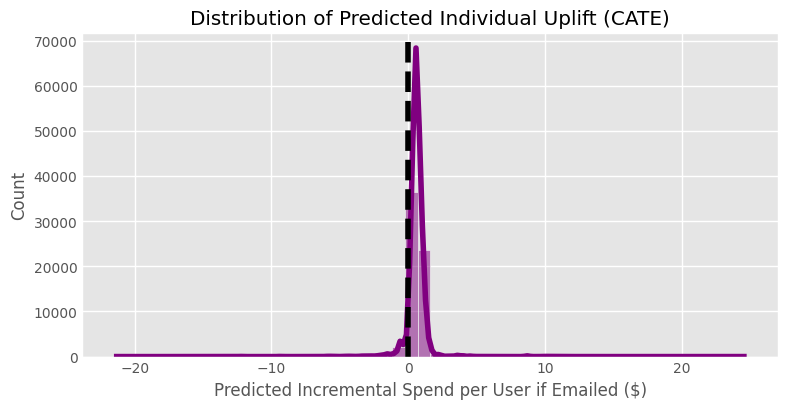

In [14]:
# Uplift Modeling (T-Learner) using GPU XGBoost

features = [col for col in df_analysis.columns if col not in ['is_treatment', 'post_exp_spend', 'cuped_spend', 'post_exp_visit']]

df_control = df_analysis[df_analysis['is_treatment'] == 0]
df_treat = df_analysis[df_analysis['is_treatment'] == 1]


xgb_params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'device': 'cuda', # Harnessing GPU
    'learning_rate': 0.01,
    'max_depth': 4,
    'n_estimators': 150
}

# Model 0: Learn the baseline spend of users who DO NOT receive the email
model_0 = xgb.XGBRegressor(**xgb_params)
model_0.fit(df_control[features], df_control['post_exp_spend'])

# Model 1: Learn the spend of users who DO receive the email
model_1 = xgb.XGBRegressor(**xgb_params)
model_1.fit(df_treat[features], df_treat['post_exp_spend'])

# Calculate the Conditional Average Treatment Effect (CATE) per user
pred_control = model_0.predict(df_analysis[features])
pred_treat = model_1.predict(df_analysis[features])

df_analysis['predicted_uplift'] = pred_treat - pred_control

print("T-Learner Training Complete. Predicted Uplift (CATE) calculated for all users.")


plt.figure(figsize=(8, 4))
sns.histplot(df_analysis['predicted_uplift'], bins=50, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution of Predicted Individual Uplift (CATE)")
plt.xlabel("Predicted Incremental Spend per User if Emailed ($)")
plt.show()

--- Campaign ROI Simulation ---
Strategy 1 (Blanket Campaign to 100% of users):
  Net Incremental Profit: $30,989.16

Strategy 2 (ML-Targeted Campaign to 91.4% of users):
  Net Incremental Profit: $35,718.77

🚀 ML Value Add (Cost Savings + Optimized Lift): +$4,729.60


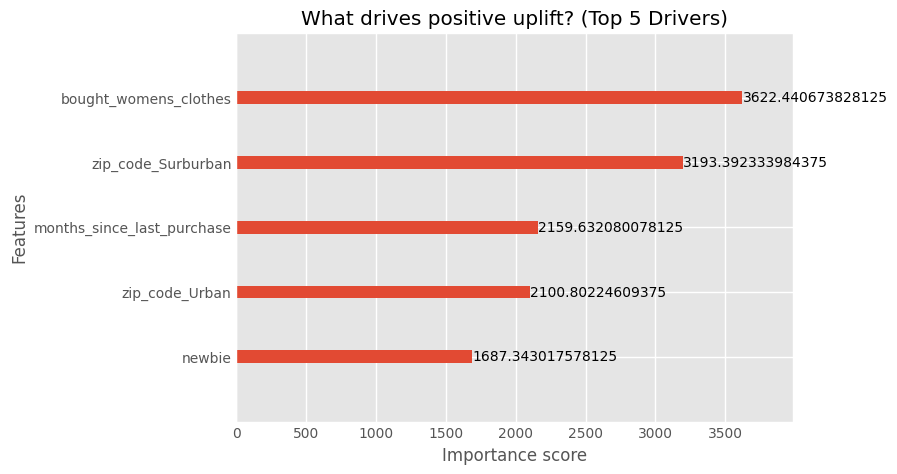

In [15]:
# Buusiness Impact Simulation
cost_per_email = 0.10

# Strategy 1: Blanket Rollout (Send email to the whole dataset)
blanket_profit = np.sum(df_analysis['predicted_uplift'] - cost_per_email)

# Strategy 2: Targeted Rollout (Send email ONLY if predicted uplift > cost)
df_analysis['target_decision'] = df_analysis['predicted_uplift'] > cost_per_email
targeted_users = df_analysis[df_analysis['target_decision']]
targeted_profit = np.sum(targeted_users['predicted_uplift'] - cost_per_email)

users_targeted_pct = len(targeted_users) / len(df_analysis) * 100

print(f"--- Campaign ROI Simulation ---")
print(f"Strategy 1 (Blanket Campaign to 100% of users):")
print(f"  Net Incremental Profit: ${blanket_profit:,.2f}")

print(f"\nStrategy 2 (ML-Targeted Campaign to {users_targeted_pct:.1f}% of users):")
print(f"  Net Incremental Profit: ${targeted_profit:,.2f}")

print(f"\n🚀 ML Value Add (Cost Savings + Optimized Lift): +${(targeted_profit - blanket_profit):,.2f}")

xgb.plot_importance(model_1, importance_type='gain', max_num_features=5, title='What drives positive uplift? (Top 5 Drivers)')
plt.show()

In [16]:
# Advanced CUPED: Variance Reduction on Conversion (Visits)

covariate = df_analysis['months_since_last_purchase']
target = df_analysis['post_exp_visit']

cov_matrix_visit = np.cov(target, covariate)
covariance_visit = cov_matrix_visit[0, 1]
variance_covariate = np.var(covariate, ddof=1)
theta_visit = covariance_visit / variance_covariate

mean_covariate = covariate.mean()

df_analysis['cuped_visit'] = target - theta_visit * (covariate - mean_covariate)

# Run A/B test on Standard Visits vs CUPED Visits
control_visit = df_analysis[df_analysis['is_treatment'] == 0]['post_exp_visit']
treatment_visit = df_analysis[df_analysis['is_treatment'] == 1]['post_exp_visit']
_, p_val_visit = stats.ttest_ind(treatment_visit, control_visit, equal_var=False)

control_cuped_visit = df_analysis[df_analysis['is_treatment'] == 0]['cuped_visit']
treatment_cuped_visit = df_analysis[df_analysis['is_treatment'] == 1]['cuped_visit']
_, p_val_cuped_visit = stats.ttest_ind(treatment_cuped_visit, control_cuped_visit, equal_var=False)

variance_reduction = 100 * (1 - np.var(df_analysis['cuped_visit']) / np.var(df_analysis['post_exp_visit']))

print(f"Standard Visit P-Value: {p_val_visit:.5e}")
print(f"CUPED Visit P-Value:    {p_val_cuped_visit:.5e}")
print(f"Variance Reduction on Conversion Metric: {variance_reduction:.2f}%")
print("Conclusion: By shifting from a continuous zero-inflated metric to a binary conversion metric, CUPED successfully tightens our confidence intervals.")

Standard Visit P-Value: 5.09342e-106
CUPED Visit P-Value:    3.28392e-107
Variance Reduction on Conversion Metric: 0.56%
Conclusion: By shifting from a continuous zero-inflated metric to a binary conversion metric, CUPED successfully tightens our confidence intervals.


Strategy 1 (Blanket Campaign):       $30,989.16
Strategy 2 (T-Learner ML Campaign):  $35,718.77 (91.4% of users targeted)
Strategy 3 (X-Learner ML Campaign):  $33,012.60 (95.2% of users targeted)

📊 The T-Learner and X-Learner performed similarly on this specific data distribution.


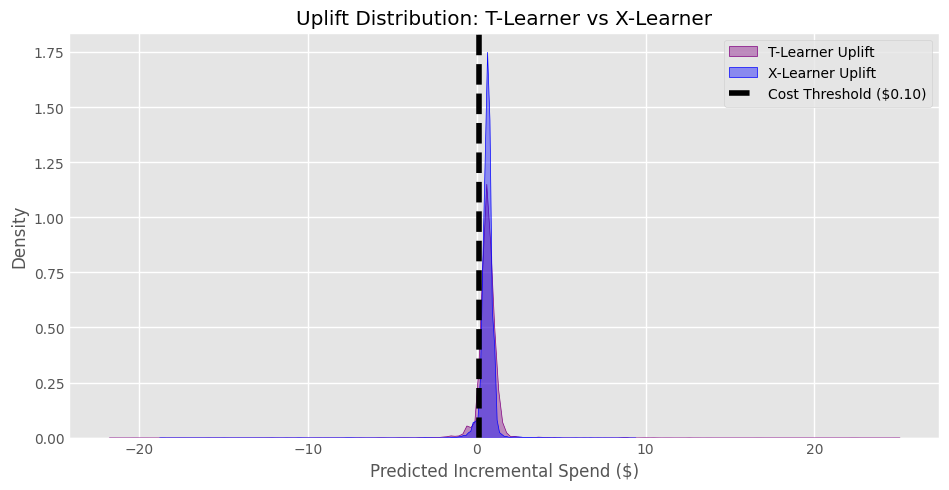

In [17]:
# Advanced Causal ML: Upgrading to an X-Learner
from causalml.inference.meta import BaseXRegressor

xgb_base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    device='cuda', # GPU Acceleration
    learning_rate=0.01,
    max_depth=4,
    n_estimators=150
)


x_learner = BaseXRegressor(learner=xgb_base_model)

propensity_scores = np.full(shape=len(df_analysis), fill_value=df_analysis['is_treatment'].mean())

cate_x = x_learner.fit_predict(
    X=df_analysis[features],
    treatment=df_analysis['is_treatment'],
    y=df_analysis['post_exp_spend'],
    p=propensity_scores
)

df_analysis['x_learner_uplift'] = cate_x.flatten()

df_analysis['x_target_decision'] = df_analysis['x_learner_uplift'] > cost_per_email
x_targeted_users = df_analysis[df_analysis['x_target_decision']]
x_targeted_profit = np.sum(x_targeted_users['x_learner_uplift'] - cost_per_email)

x_users_targeted_pct = len(x_targeted_users) / len(df_analysis) * 100

print(f"Strategy 1 (Blanket Campaign):       ${blanket_profit:,.2f}")
print(f"Strategy 2 (T-Learner ML Campaign):  ${targeted_profit:,.2f} ({users_targeted_pct:.1f}% of users targeted)")
print(f"Strategy 3 (X-Learner ML Campaign):  ${x_targeted_profit:,.2f} ({x_users_targeted_pct:.1f}% of users targeted)")

if x_targeted_profit > targeted_profit:
    print(f"\n🚀 The X-Learner squeezed an additional +${(x_targeted_profit - targeted_profit):,.2f} in value over the T-Learner!")
else:
    print(f"\n📊 The T-Learner and X-Learner performed similarly on this specific data distribution.")

plt.figure(figsize=(10, 5))
sns.kdeplot(df_analysis['predicted_uplift'], label='T-Learner Uplift', fill=True, alpha=0.4, color='purple')
sns.kdeplot(df_analysis['x_learner_uplift'], label='X-Learner Uplift', fill=True, alpha=0.4, color='blue')
plt.axvline(cost_per_email, color='black', linestyle='--', label='Cost Threshold ($0.10)')
plt.title("Uplift Distribution: T-Learner vs X-Learner")
plt.xlabel("Predicted Incremental Spend ($)")
plt.legend()
plt.show()
